# TD 1 : Introduction à R et aux Statistiques descriptives

Christelle Gonindard, Matthias Grenié, et François Bettega

<div class="alert alert-info">

## Objectifs

- Découvrir l'utilisation de R
- Comprendre ce que sont les **variables**, les **fonctions** et les **arguments**
- Lire un jeu de données sur R
- Calculer des indicateurs de position et de dispersion sur des données
- Visualiser des données quantitatives et qualitatives avec R

</div>

## 1. Introduction

Ces Cours-TD visent à vous donner le recul nécessaire pour interpréter les analyses statistiques que vous rencontrerez dans votre cursus et votre vie professionnelle. L'objectif n'est pas de former des statisticiens, mais de vous rendre capables de comprendre une méthode, d'en repérer les limites, et de distinguer une conclusion solide d'une conclusion abusive.

Les statistiques sont indissociables du domaine de la santé : essais cliniques, études épidémiologiques, contrôle qualité, ou encore études omiques (génomique, transcriptomique...) produisent des masses de données qu'il est illusoire de traiter à la main. Pendant cette UE, nous utiliserons [R](https://www.r-project.org/), un langage de programmation libre et gratuit dédié aux statistiques, largement utilisé en recherche, dans les administrations (INSEE, ANSES) et dans l'industrie (ex. laboratoires pharmaceutiques).

Cette UE vous demande donc de :
- mobiliser vos connaissances biologiques pour interpréter les données et les résultats,
- comprendre les principes des méthodes statistiques pour choisir la bonne selon l'échantillon et la question posée,
- vous familiariser avec la programmation en R.

## 2. Introduction à la programmation avec R

### 2.1 R comme une calculatrice

Le langage de programmation R peut directement être utilisé comme une grosse calculatrice, avec les opérateurs habituels : addition **`+`**, soustraction **`-`**, multiplication **`*`**, division **`/`** et puissance **`^`**. Les nombres à virgule s'écrivent avec un point **`.`** (notation anglophone) et suivent les mêmes règles.  
Une fois que vous avez tapé vos instructions, exécutez le bloc de code avec `Ctrl + Entrée` (sur PC) ou `Cmd + Entrée` (sur Mac), ou avec le bouton "Play" (▶️) en haut de ce notebook.  
Essayez ci-dessous les différentes opérations :

In [1]:
# Addition, soustraction, multiplication, division, puissance
10 + 5
20 - 8
4 * 6
50 / 2
2^3

# Ça fonctionne aussi avec des nombres à virgule (notation avec un point)
0.5 + 0.5

[1] 15

[1] 12

[1] 24

[1] 25

[1] 8

[1] 1

Le code s'exécute de manière séquentielle en lisant les lignes au fur et à mesure, et affiche les résultats sous le bloc de code concerné.

💡 **Note** : Les lignes qui commencent par `#` sont des commentaires et ne sont pas exécutées par R. Vous pouvez vous en servir pour expliquer ce que le code que vous avez écrit effectue. Cela est pratique pour l'annoter sans avoir à écrire du texte à côté.

R contient par défaut de nombreuses fonctions mathématiques usuelles que l'on peut mobiliser directement : `exp()`, pour la fonction exponentielle ; `cos()`, pour la fonction cosinus ; `sin()`, pour la fonction sinus ; `sqrt()`, pour la fonction racine carrée (_**sq**uare-**r**oo**t**_ en anglais).  

In [5]:
# Utilisation de fonctions mathématiques
exp(1)
exp(0)

[1] 2.718282

[1] 1

On peut aussi créer des variables qualitatives en utilisant des guillemets `"`. Pour cela il faut écrire des mots entre guillemets. Il s'agit d'une valeur de type **caractère**. 

Créez la valeur qualitative `"oui"`.

In [6]:
"oui"
"bla"

[1] "oui"

[1] "bla"

On ne peut pas utiliser les opérateurs sur les variables qualitatives

### 2.2 Stocker des valeurs avec les variables

Maintenant que l'on peut manipuler des nombres, il peut être intéressant de pouvoir les stocker pour pouvoir les manipuler ensuite.  
On va le faire à travers des **variables**. Une variable est une valeur ou un objet stocké, avec un nom, qui peut réutilisé dans la suite de la session.

Pour créer une variable sur R, il faut qu'on lui **assigne** une valeur avec l'opérateur **`=`**. On va écrire le nom de la variable à gauche du signe `=` et à droite la valeur qu'on veut y stocker. Pour réutiliser la variable, on peut ensuite directement faire appel à son nom et le manipuler dans les opérations qu'on a vu au-dessus.

Créez une variable `patient` qui vaut 3, affichez la, puis ajouter 2 à `patient`

In [7]:
patient = 3

patient

patient + 2

patient  # La valeur de patient n'est pas modifiée !

[1] 3

[1] 5

[1] 3

### 2.3 Travailler avec plusieurs valeurs en utilisant les vecteurs

La plupart du temps, on est intéressés par plusieurs valeurs ensemble, pour cela on va créer ce qui s'appelle un **vecteur** sur R en utilisant la fonction **`c()`**. Cette fonction permet de **c**oncaténer des valeurs en les séparant par des virgules **`,`**.  
Rentrez les valeurs suivantes de fréquences cardiaques : 67, 63, 57, 55, 69, 68, 65, 58, 51, 52

In [1]:
# Créez votre premier vecteur !
c(67, 63, 57, 55, 69, 68, 65, 58, 51, 52)

# Vous pouvez aussi créez une variable qui contient ces valeurs
frequences = c(67, 63, 57, 55, 69, 68, 65, 58, 51, 52)

frequences

# Et vous pouvez aussi faire des opérations avec (toutes les valeurs sont affectées)
frequences + 10

frequences * 2

[1] 67 63 57 55 69 68 65 58 51 52

[1] 67 63 57 55 69 68 65 58 51 52

[1] 77 73 67 65 79 78 75 68 61 62

[1] 134 126 114 110 138 136 130 116 102 104

### 2.4 Combiner des vecteurs dans un tableau : les *data.frames*


Maintenant qu'on des vecteurs, on peut créer des tableaux qui mélangent des types de variables différents. Ces tableaux sont des objets à part entière dans R et s'appellent des _**data.frame**_. Pour les créer il faut utiliser la fonction `data.frame()`, en donnant des noms avec des vecteurs comme listes de valeurs.

Nous allons créer un data.frame qui contient des fréquences cardiaques de patients et leurs identifiants

In [9]:
# Création d'un data frame
data.frame(
    id = c(1, 2),
    frequence_cardiaque = c(67, 63),
    groupe_sanguin = c("A", "O")
)

id,frequence_cardiaque,groupe_sanguin
<dbl>,<dbl>,<chr>
1,67,A
2,63,O


On observe que le data.frame s'affiche spécifiquement. L'affichage montre plusieurs choses :

- `2 x 3` donne le nombre de lignes (2) puis le nombre de colonnes (3),
- les noms des colonnes en gras (**`id`**, **`frequence_cardiaque`**, et **`groupe_sanguin`**),
- les types de colonnes (**\<dbl\>**, pour des nombres, _**d**ou**bl**e_ en anglais ; **\<chr\>**, pour des types caractères, _**ch**a**r**acter_).

Créez un data.frame avec au moins 3 colonnes et 2 lignes, de votre choix.

In [10]:
# data.frame à créer

data.frame(
    patient  = c("patient1", "patient2", "patient3", "patient4"),
    diabete  = c("oui", "oui", "non", "non"),
    glycemie = c(1.2, 1, 0.9, 0.95),
    taille   = c(165, 166, 178, 191)
)

patient,diabete,glycemie,taille
<chr>,<chr>,<dbl>,<dbl>
patient1,oui,1.20,165
patient2,oui,1.00,166
patient3,non,0.90,178
patient4,non,0.95,191


Maintenant qu'on a compris comment créer des objets sur R, on va pouvoir travailler sur de vraies données et calculer des indicateurs.

## 3. Présentation des données

Lors des trois premiers TD nous allons étudier le même jeu de données. Il s'agit d'un jeu de données qui cherche à savoir si l'acupuncture peut avoir un effet sur la dépression.

Un clinicien évalue l’intensité de la dépression sur l’échelle de Hamilton qui varie de 0 (non
déprimé) à 56 (très déprimé), chez 100 patients souffrant d’un Episode Dépressif Majeur (EDM).
On veut savoir si l’acupuncture améliore l’évolution de la dépression. Pour cela, 100 malades
de même état dépressif (même score de Hamilton) sont répartis en 2 groupes de 50 par tirage
au sort. Le groupe I a reçu uniquement le traitement pharmacologique et le groupe II a reçu le
traitement pharmacologique associé à de l’acupuncture.

Le jeu de données contient les variables suivantes en colonne :
- `hamilton_g1` : Les scores de Hamilton, après 8 mois de traitement pour le groupe 1 ;
- `hamilton_g2` : Les scores de Hamilton, après 8 mois de traitement pour le groupe 2 ;
- `age_g1` : l’âge des patients du groupe 1 ;
- `age_g2` : l’âge des patients du groupe 2 ;
- `poids_g1` : le poids des patients du groupe 1 ;
- `poids_g2` : le poids des patients du groupe 2 ;
- `sexe_g1` : le sexe des patients du groupe 1 (`"F"` : femme, `"H"` : homme) ;
- `sexe_g2` : le sexe des patients du groupe 2 (`"F"` : femme, `"H"` : homme) ;
- `urbanisation_g1` : le niveau d’urbanisation dans lequel vivent les patients du groupe 1 (`"A"` : rural, `"B"` : urbanisation modéré, `"C"` : fortement urbanisé) ;
- `urbanisation_g2` : le niveau d’urbanisation dans lequel vivent les patients du groupe 2 (`"A"` : rural, `"B"` : urbanisation modéré, `"C"` : fortement urbanisé).

Les données sont contenues dans le fichier texte nommé `depression.txt` qui se trouve dans le dossier `data`. Le chemin d'accès complet du fichier est donc `data/depression.txt`.

Pour lire les données sur R, il faut utiliser la fonction `read.table()`. On appelle **fonction** les instructions de R qui sont déjà existantes et peuvent être réutilisées (par analogie avec les fonctions mathématiques). Certaines fonctions peuvent s'utiliser toutes seules. D'autres nécessitent qu'on précise ce sur quoi on les applique, ce sont les **arguments**.

Ici, `read.table()` nécessite que l'on précise le chemin d'accès du fichier comme premier argument pour pouvoir lire les données, on peut préciser un autre argument appelé `header =` qui permet de dire à R que le fichier contient comme première ligne les entêtes de colonnes.

In [11]:
# L'argument header = TRUE (/!\ Il faut respecter les majuscules /!\)
# qui signifie 'header est vrai' permet de préciser que le fichier de données 
# possède une ligne en début qui correspond au nom des colonnes

read.table("data/depression.txt", header = TRUE)

hamilton_g1,hamilton_g2,urbanisation_g1,urbanisation_g2,age_g1,age_g2,poids_g1,poids_g2,sexe_g1,sexe_g2
<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>
43,25,B,B,57,48,74,93,F,H
29,29,A,B,37,41,95,92,H,H
34,18,A,A,7,30,84,86,H,H
39,23,A,A,37,41,104,81,H,H
40,24,B,A,15,30,92,74,H,F
41,25,B,B,45,45,85,98,H,H
32,27,A,B,41,41,79,75,H,H
36,16,A,A,33,17,92,90,H,H
35,27,A,B,55,47,76,83,H,H


Pour l'instant on n'a fait que charger et afficher le tableau. Il n'est pas encore utilisable.
Pour le faire il faut créer une **variable** qui contiendra le tableau qu'on utilisera pour le reste de la séance.
Nous pouvons nommer le tableau `depression`. Pour assigner une variable dans R, on peut utiliser le signe `=`, à gauche du signe `=` on indique le nom de la variable, tandis que la droite du signe `=` donne le contenu de la variable.

In [12]:
depression = read.table("data/depression.txt", header = TRUE)

Rien ne s'affiche, c'est **normal**. Car on vient de créer la variable, pour l'afficher il faut utiliser le nom qu'on lui a donné directement :

In [13]:
depression

hamilton_g1,hamilton_g2,urbanisation_g1,urbanisation_g2,age_g1,age_g2,poids_g1,poids_g2,sexe_g1,sexe_g2
<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>
43,25,B,B,57,48,74,93,F,H
29,29,A,B,37,41,95,92,H,H
34,18,A,A,7,30,84,86,H,H
39,23,A,A,37,41,104,81,H,H
40,24,B,A,15,30,92,74,H,F
41,25,B,B,45,45,85,98,H,H
32,27,A,B,41,41,79,75,H,H
36,16,A,A,33,17,92,90,H,H
35,27,A,B,55,47,76,83,H,H


*Note : si vous cherchez de l'aide en ligne ou ailleurs sur R, vous pouvez voir que certaines personnes assignent des variables avec les caractères `<-`, c'est strictement équivaleut au signe `=`, aussi, par simplicité , dans le reste du cours nous utiliserons le signe `=`*

Un tableau peut contenir plusieurs milliers de lignes tout afficher peut donc être inutile.

La fonction `head()` permet d'afficher les premières lignes d'un tableau (sans autre précision, les **six premières**).

In [14]:
# Afficher le début du contenu du fichier de données 
head(depression)

,hamilton_g1,hamilton_g2,urbanisation_g1,urbanisation_g2,age_g1,age_g2,poids_g1,poids_g2,sexe_g1,sexe_g2
,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>
1,43,25,B,B,57,48,74,93,F,H
2,29,29,A,B,37,41,95,92,H,H
3,34,18,A,A,7,30,84,86,H,H
4,39,23,A,A,37,41,104,81,H,H
5,40,24,B,A,15,30,92,74,H,F
6,41,25,B,B,45,45,85,98,H,H


Les tableaux dans R portent le nom de `data.frame`.

Par analogie avec les mathématiques, quand on s'intéresse à un ensemble en une seule dimension, comme une colonne de tableau par exemple, on parle en R de **vecteur**.

Pour extraire une colonne d'un tableau on doit préciser le nom du tableau suivi de `$` suivi du nom de la colonne (**/!\\** en respectant scrupuleusement l'orthographe **/!\\**)

In [15]:
# Pour avoir accès aux colonnes, il faut préciser le nom du tableau
depression$hamilton_g1

[1] 43 29 34 39 40 41 32 36 35 37 43 36 41 37 33 40 38 43 32 32 44 40 36 37 41
[26] 43 37 31 47 41 45 42 46 35 49 33 34 44 40 42 44 40 29 36 42 44 32 37 42 45

Si vous faites une faute d'orthographe alors vous obtiendrez la valeur spéciale `NULL`, qui signifie que l'objet est vide

In [16]:
# Colonne avec un faute d'orthographe, qui n'existe pas
depression$hamilton_g

NULL

Pour éviter de faire des fautes d'orthographes dans les noms de colonnes, n'hésitez pas utiliser la touche tabulation souvent notée **`Tab`**, elle permet de faire de l'**auto-complétion** en affichant les noms de colonnes disponibles dans le tableau. N'hésitez pas à vous en servir


![image](figures/fig_tab1.png)

Si on tape le début d'un nom de colonne alors cela restreint la liste affichée  

![image](figures/fig_tab2.png)

Vous pouvez naviguer dans la liste affichée avec les flèches de votre clavier, ou bien cliquer sur le nom de colonnes qui vous intéresse.

## 4. Statistiques descriptives

La statistique descriptive est la première étape primordiale lors d’une analyse statistique,
cette étape va permet bien évidemment de résumer ou représenter les données observées, avec
le moins de mots, chiffres ou graphiques possible, grâce à des outils statistiques simples tels que
la moyenne, la médiane, la variance, les quantiles, le maximum, le minimum....
Elle permet également de vérifier si il n’y a pas de valeurs erronées, de problèmes d’échantillonnage.

Elle a aussi un rôle de suggestion d’hypothèses pour des études plus approfondies ou encore de vérification de condition d’application pour les tests statistiques de l’étude infférentielle qui
suivra.

### 4.1 Type de variable

Les variables du jeu de données peuvent prendre un certain nombre de valeurs sans que
celles-ci ne puissent être prévues à priori, c’est pour cela qu’elle se nomme variable aléatoire. Il
existe deux types de variables aléatoires :
- Variable **qualitative** : modalité non mesurable, par exemple la couleur des yeux, le sexe,
le groupe sanguin, etc.
- Variable **quantitative** : modalité mesurable, par exemple la taille, le taux d’hormones, etc.

Une variable aléatoire est dite **discrète** si elle prend que des valeurs discontinues dans un
intervalle donné, comme par exemple le nombre d’enfants dans une famille, le nombre de fumeurs, etc.

Une variable aléatoire est dite **continue** si elle prend toutes les valeurs dans un intervalle donné,
comme par exemple : la taille, le poids, etc.

Dans notre exemple de cours, les variables `hamilton`, `age`, `poids` sont des variables **quantitatives**
alors que les variables `sexe` et `urbanisation` sont des variables **qualitatives**.

### 4.2 Paramètres utilisés en statistique descriptive

Lors de la description d’un jeu de données, deux types de paramètres doivent être utilisés
pour décrire les variables quantitatives : les paramètres de position et les paramètres de dispersion.

#### Paramètres de position

1. la **moyenne** : c’est la somme pondérée des valeurs mesurées 
2. la **médiane** : c’est la valeur qui scinde l’échantillon en deux de telle sorte que 50% desobservations sont supérieures à cette valeur et 50% des observations lui sont inférieures.

Comparaison de ces deux indicateurs :

1. la **moyenne** : c’est l’indicateur familier, intuitif et facile à calculer.
   point faible : il n’est pas robuste =  très sensible au changement d’une ou plusieurs observations et aux valeurs extrêmes
3. la **médiane** : c’est un indicateur à fois précis et robuste = il est peu sensible à la modification d’une ou plusieurs observations ou aux valeurs extrêmes

Remarque : tout au long des TDs vous trouverez dans les encadrés les instructions en langage R pour réaliser les analyses statistiques.

Pour calculer la moyenne d'un vecteur sur R, on doit utiliser la fonction `mean()` (*mean* qui signifie moyenne en anglais).  
Pour la médiane, il faut utiliser la fonction `median()` (*median* qui signifie médiane en anglais).

Calculons les moyennes et médianes des scores de Hamilton du groupe 1.

In [17]:
# Traitement pharmacologique
# Moyenne de la variable hamilton_g1
mean(depression$hamilton_g1)

# Médiane de la variable hamilton_g1
median(depression$hamilton_g1)

[1] 38.78

[1] 40

*Application* : calculer les moyennes et médianes des variables `hamilton_g2`, `age_g1`, et `age_g2`

In [18]:
mean(depression$hamilton_g2)
mean(depression$age_g1)
mean(depression$age_g2)

[1] 24.54

[1] 40.42

[1] 36.88

On constate que l’âge moyen dans les groupes 1 et 2 sont proches, respectivement environ 40
ans et 37 ans. En revanche, la différence au niveau du score de Hamilton semble plus importante
entre le groupe 1 et 2 avec des scores moyens respectivement de 38.8 et 24.5, et des scores
médians respectivement de 40 et 25. Toutefois, il est important de vérifier la dispersion des
données car même si la la différence de moyenne entre les deux groupes peut sembler importante,
deux cas de figures se présentent :
- si l’écart-type pour les deux groupes est également grand alors cette différence s’amenuise,les données se chevauchent
- si l’écart-type est faible alors les deux groupes ont des données bien distinctes et la différence entre les deux groupes apparait clairement. 

<img src="figures/fig_dispersion.jpg" />


#### Paramètres de dispersion

Ils fixent la variabilité des mesures par rapport à un paramètre de position.
1. la **variance** : c’est l’écart par rapport à la moyenne, l'écart-type correspond à la racine de la variance
2. l’**amplitude** : c’est l’écart entre la plus grande et la plus petite valeur observée dans l’échantillon.
3. l’**intervalle inter-quartile** : c’est la plage de valeurs délimitée par le 1er quartile et le 3ème quartile (respectivement Q1 et Q3). Il contient 50% des observations : 25% de part et d’autre de la médiane. Les quartiles sont définis sur le même principe que la médiane (aussi nommé 2ème quartile).

**le premier quartile (Q1)** : c’est la valeur qui scinde l’échantillon en deux de telle sorte que 75% des observations
sont supérieures à cette valeur et 25% des observations lui sont inférieures.

**le troisième quartile (Q3)** : c’est la valeur qui scinde l’échantillon en deux de telle sorte que 25% des observations
sont supérieures à cette valeur et 75% des observations lui sont inférieures.

Si l'on compare ces trois indicateurs, ils ont différentes propriétés :
1. l’écart-type : c’est un indicateur peu robuste, mais facile à calculer et récurrent dans les statistiques inférentielles
2. l’intervalle inter-quartile : c’est un indicateur robuste au même titre que les valeurs qui le caractérisent (quartiles).
3. l’amplitude : facile à calculer, mais très sensible aux valeurs extrêmes (qui sont parfois aberrantes).

Pour calculer l'écart-type d'un vecteur sur R, il faut utiliser la fonction `sd()` (écart-type se dit ***s**tandard **d**eviation* en anglais).  
Pour l'intervalle inter-quartile et l'amplitude, ils nous sont donnés *via* la fonction `summary()` (résumé en anglais) qui nous permet d'obtenir un résumé statistique du vecteur.

*Application au jeu de données sur le score de Hamilton :*

In [19]:
# Moyenne de la variable hamilton_g1
mean(depression$hamilton_g1)

# Médiane de la variable hamilton_g1
median(depression$hamilton_g1)

# Écart-type de la variable hamilton_g1
sd(depression$hamilton_g1)

# Résumé statistique de la variable hamilton_g1
summary(depression$hamilton_g1)

[1] 38.78

[1] 40

[1] 4.896021

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  29.00   35.25   40.00   38.78   42.75   49.00 

Faites de même pour la variable `hamilton_g2`

In [20]:
# Moyenne de la variable hamilton_g2
mean(depression$hamilton_g2)

# Médiane de la variable hamilton_g2
median(depression$hamilton_g2)

# Ecart-type de la variable hamilton_g2
sd(depression$hamilton_g2)

# Résumé statitistique de la variable hamilton_g2
summary(depression$hamilton_g2)

[1] 24.54

[1] 25

[1] 5.006975

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  15.00   20.50   25.00   24.54   28.00   36.00 

**En conclusion** :  
Les deux résumés statistiques des scores de Hamilton pour les groupes
1 et 2 montrent une non-superposition des deux groupes : le groupe 1 a des scores de Hamilton
sensiblement plus forts que le groupe 2. Ainsi, dans le groupe 2, 75% des données sont
inférieures à 28 alors que dans le groupe 1, 75% des valeurs sont supérieures à 35.25. Cette
première observation permet de faire l’hypothèse suivante :
*Il semblerait que le score de Hamilton soit plus faible dans le groupe 2 que dans le groupe 1, ce
qui irait dans le sens de dire que l’acupuncture apporte un effet bénéfique dans le traitement de
la dépression.*
Cette hypothèse pourra ensuite être testée dans les TDs suivants par un test de comparaison de
moyennes.

### 4.3 Représentation des variables quantitatives

#### Histogramme

L’histogramme est un moyen rapide pour étudier la répartition d’une variable.  
Cependant, il faut faire attention car la forme de l’histogramme change en fonction de l’amplitude
des classes, il faut tester plusieurs découpages différents.

[Philippe Besse (Professeur de Statistiques, auteur du site WikiStat)](http://wikistat.fr/) :
> La qualité de l’estimation d’une distribution par un histogramme dépend beaucoup
du découpage en classes.  
> Malheureusement, plutôt que de fournir des classes d’effectifs égaux
et donc de mieux répartir l’imprécision, les logiciels utilisent des classes d’amplitudes égales et
tracent donc des histogrammes parfois peu représentatifs.

Pour représenter un histogramme sur R, il faut utiliser la fonction `hist()` en donnant comme argument le vecteur duquel on veut l'histogramme.

*Application au jeu de données sur le score de Hamilton :*

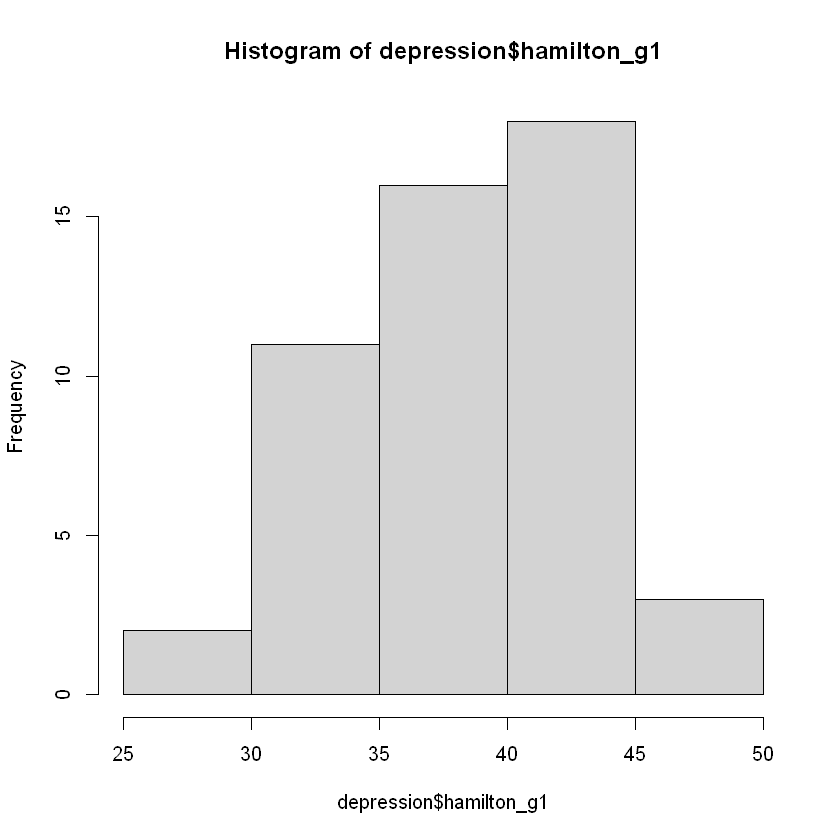

In [21]:
# tracer de l'histogramme représentant la variable hamilton_g1
hist(depression$hamilton_g1)

Tracer l'histogramme de la colonne `hamilton_g2` et comparer avec l'histogramme de la colonne `hamilton_g1`

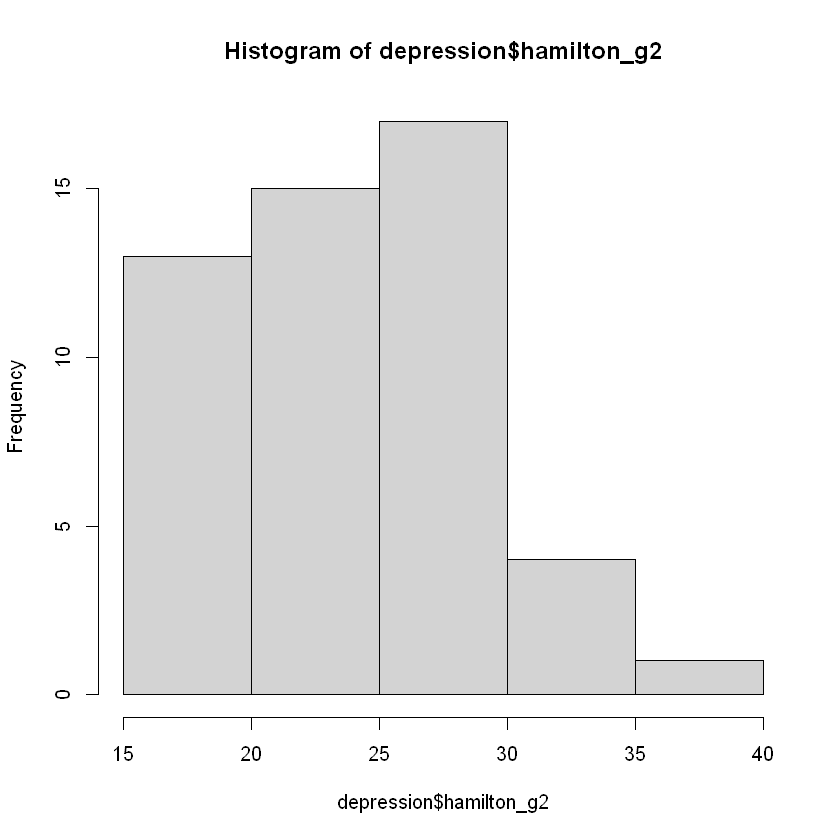

In [22]:
# tracer de l'histogramme représentant la variable hamilton_g1
hist(depression$hamilton_g2)

Ces histogrammes montrent une répartition disymétrique du score de Hamilton pour les
groupes g1 et g2 avec un **mode** (c'est-à-dire la valeur ou classe la plus fréquente) respectivement aux alentours de 40-45 et 25-30.

On peut choisir le nombre de classes de l’histogramme avec l'argument `n=` suivi d'un nombre, ce qui permet d’augmenter (ou de réduire)
la précision du graphique.

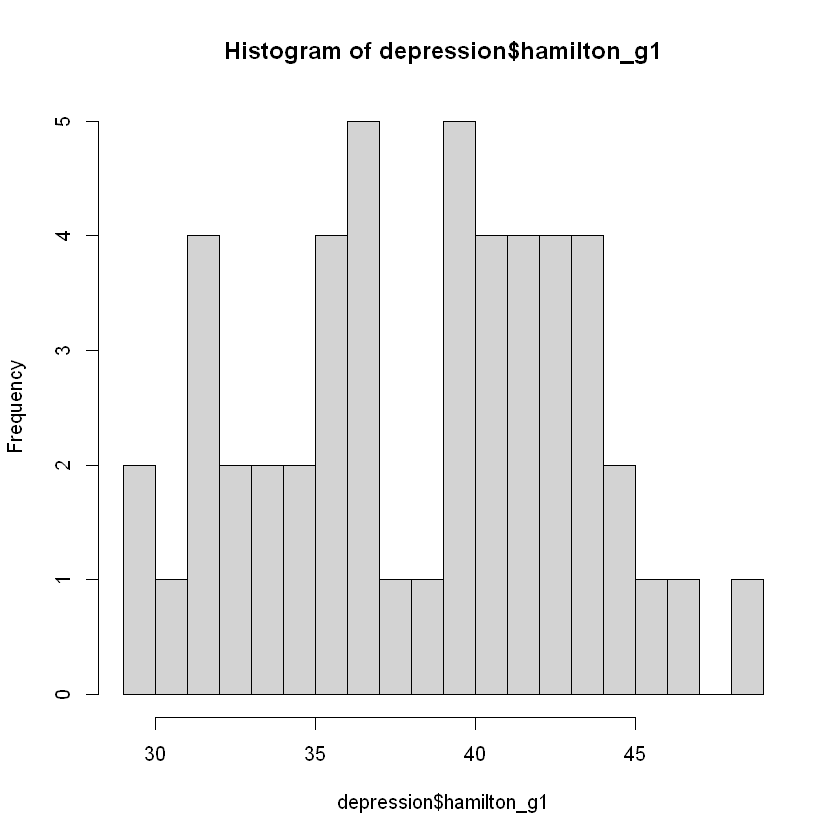

In [23]:
# tracer de l'histogramme représentant la variable hamilton_g1, en choisissant 15 classes grâce à l'argument n=15
hist(depression$hamilton_g1, n = 15)

Retracer l'histogramme de la variable `hamilton_g2` avec 15 classes

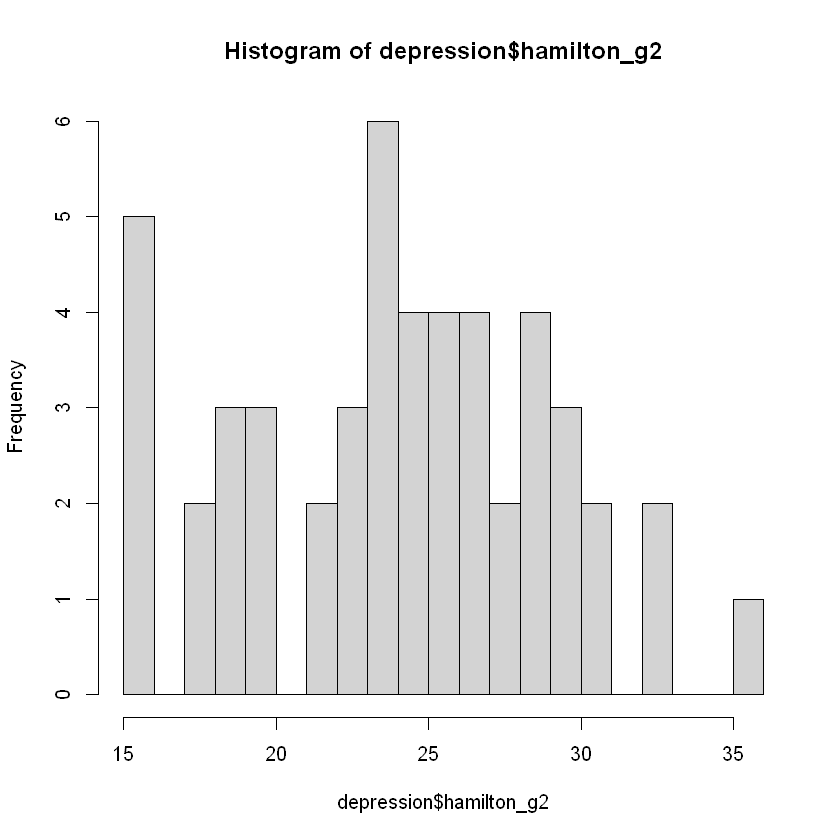

In [24]:
hist(depression$hamilton_g2, n = 15)

Ces histogrammes ont été obtenus à partir des mêmes données que les histogrammes précédents,
seul le nombre de classes a été changé. Les deux distributions semblent pourtant très
différentes.  
Il est important d’ajuster le nombre de classes en fonction de la taille de l’échantillon.

#### *boxplot* (ou diagramme en boîte à moustaches)

Ce type de graphique permet de résumer une série statistiques, d’identifier
les valeurs extrêmes, de comprendre la répartition des observations (dispersion et symétrie)
d’une variable ou encore de comparer la répartition des données d’une même variable entre plusieurs
échantillons.

- La valeur centrale du graphique est la **médiane** (il existe autant de valeurs supérieures qu’inférieures à cette valeur dans l’échantillon), on la représente par une barre plus épaisse.
- Les bords du rectangle sont les quartiles **Q1** et **Q3** (Pour le bord inférieur, un quart des observations ont des valeurs plus petites et trois quart ont des valeurs plus grandes, le bord supérieur suit le même raisonnement).
- Les extrémités des moustaches sont calculées en utilisant 1.5 fois l’espace interquartile (Q3 - Q1).
On peut remarquer que 50% des observations se trouvent à l’intérieur de la boîte (et donc 50% en dehors !).

Les valeurs à l’extérieur des moustaches sont représentées par des points. Ces valeurs peuvent
être décrites comme extrêmes par rapport aux autres valeurs de l’échantillon. Toutefois, il ne
faut pas faire de raccourci rapide et en déduire que se sont forcément des valeurs aberrantes.
Par contre, cela peut indiquer qu’il faut étudier ces observations plus en détails.

Pour représenter un *boxplot* sous R il faut utiliser la fonction `boxplot()` en donnant comme argument la série statistique que l'on souhaite représenter.  

*Application au jeu de données sur le score de Hamilton :*

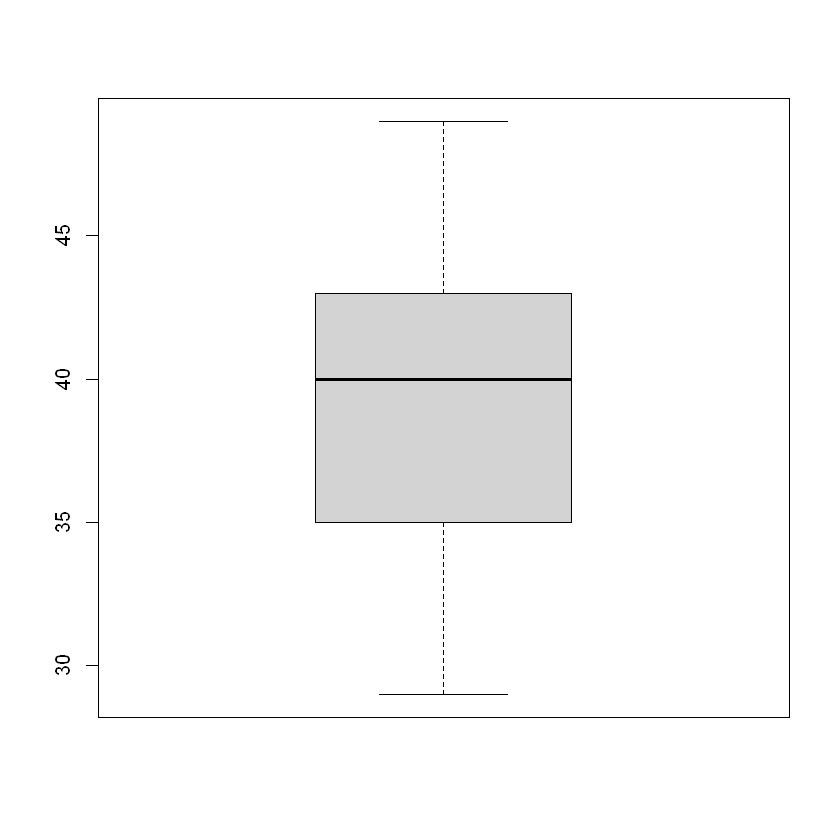

In [25]:
# l'argument main permet de préciser un titre
# l'argument ylab permet de préciser un titre à l'axe de y
boxplot(depression$hamilton_g1)

Les graphiques de R par défaut utilisent les noms de variables fournies pour donner des titres aux axes et aux graphiques. Pour les modifier, on peut utiliser les argumants `main=` pour donner le titre général du graphique et l'argument `ylab=` pour nommer l'axe des ordonnées (raccourci de ***y**-axis **lab**el*).
Il faut fournir ces titres en écrivant entre guillemets `"`

Reprenez le boxplot ci-dessus et donnez lui un titre et nommez l'axe des ordonnées

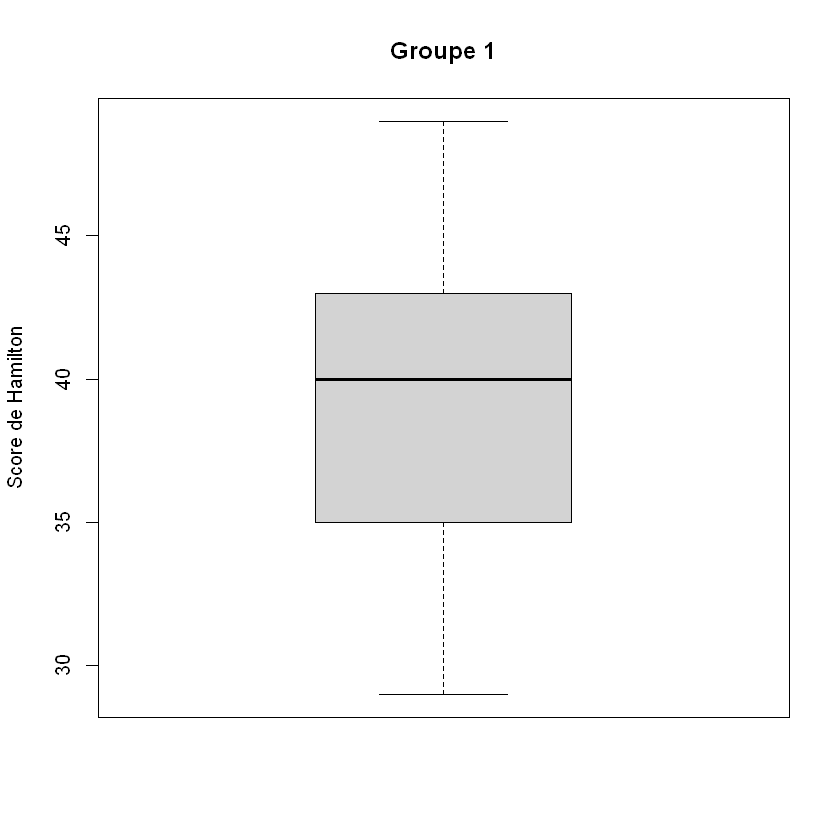

In [26]:
boxplot(depression$hamilton_g1, main = "Groupe 1", ylab = "Score de Hamilton")

De la même façon, tracez le boxplot de la variable `hamilton_g2`

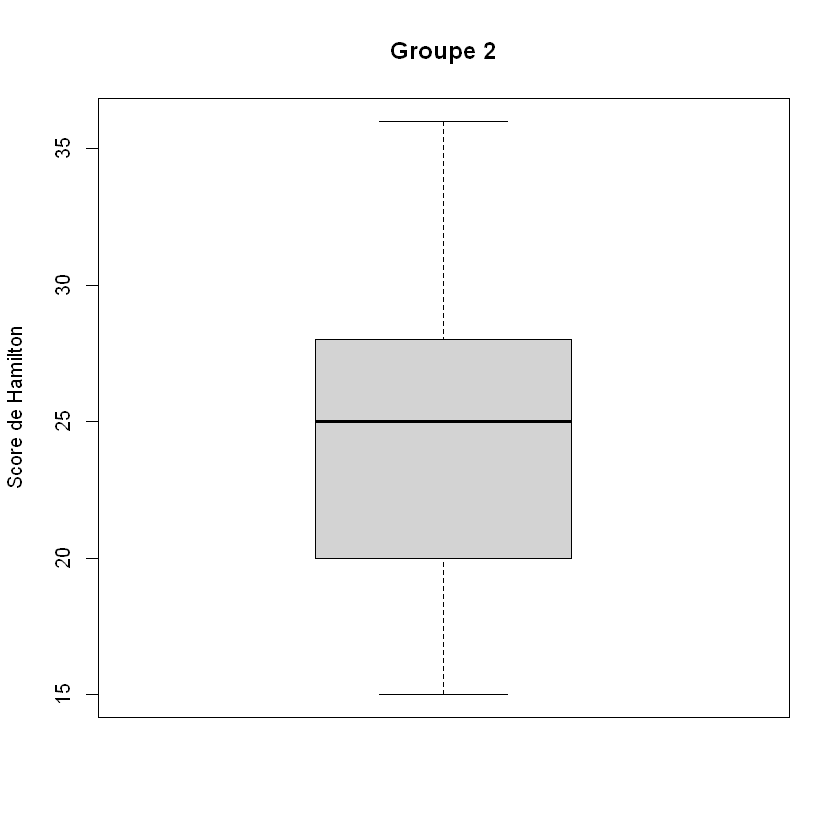

In [27]:
boxplot(depression$hamilton_g2, main = "Groupe 2", ylab = "Score de Hamilton")

Il est possible de regrouper les deux boxplots sur la même figure en donnant les deux séries statistiques d'affilées à la fonction `boxplot()`.
On peut préciser l'axe des abscisses avec l'argument `xlab=` (pour ***x**-axis **lab**el*)

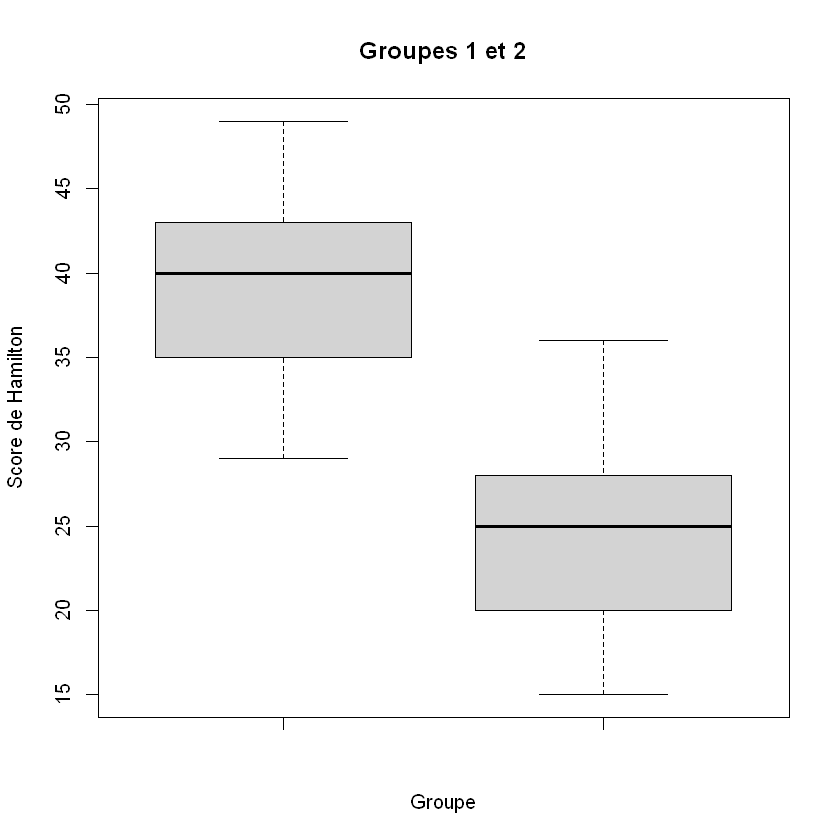

In [28]:
# On peut les annoter de la même façon
boxplot(depression$hamilton_g1, depression$hamilton_g2, main = "Groupes 1 et 2", ylab = "Score de Hamilton", xlab = "Groupe")

Seulement les noms de groupes n'apparaissent plus, pour ce faire on peut utiliser l'argument `names=` suivi d'un vecteur de nom.

Pour créer un vecteur de nom il faut utiliser la fonction `c()` en séparant les noms entre guillemets `"` par des virgules, par exemple `c("A", "B")`.

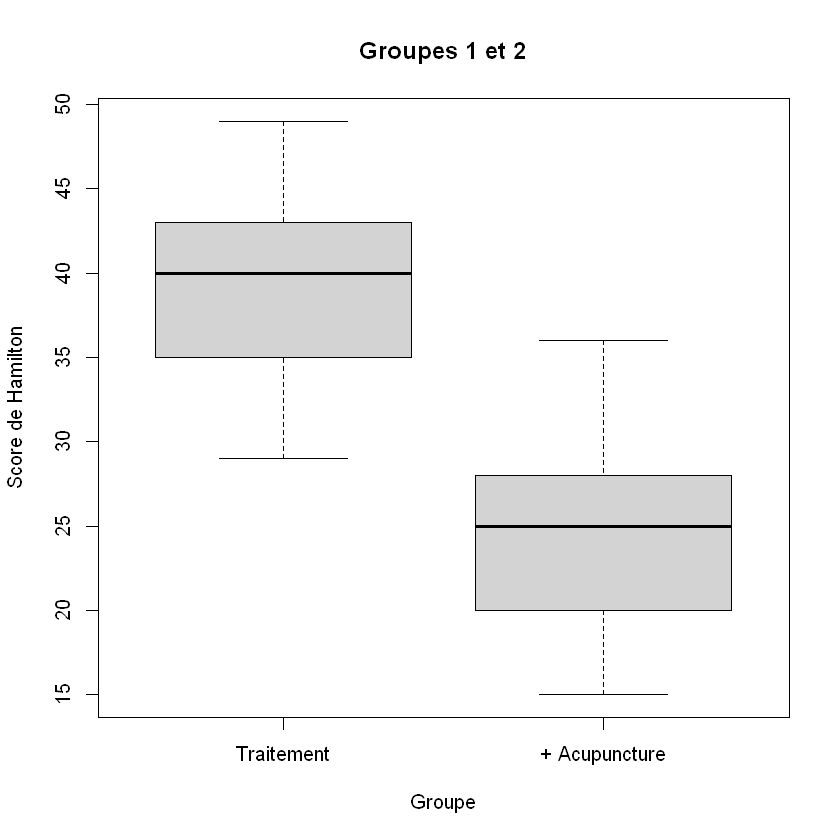

In [29]:
boxplot(depression$hamilton_g1, depression$hamilton_g2, main = "Groupes 1 et 2", ylab = "Score de Hamilton", xlab = "Groupe", names = c("Traitement", "+ Acupuncture"))

*Note : pour faciliter la lecture du code, n'hésitez pas à revenir à la ligne après chaque virgule dans les fonctions, cela permettra d'aérer votre code et d'identifier plus rapidement les bugs*

**Interprétation** :

Sur les boxplots ci-dessus, on observe que le score de Hamilton médian est supérieur
dans le groupe qui n’a pas eu d’acupuncture. De plus, la répartition des scores entre les deux
classes est également différente d’après ces boxplots, en effet, le troisième quartile du groupe
ayant eu un complément avec de l’acupuncture est largement en dessous du premier quartile du
groupe qui n’a pas eu d’acupuncture.
Ces boxplots suggérent l’hypothèse que l’acupuncture aiderait au traitement de la dépression (en supplément d'un traitement pharmacologique).
Cette hypothèse sera vérifiée statistiquement dans le chapitre suivant.

Il peut également être observé que dans les deux groupes la répartition des données apparait
comme symétrique par rapport à la médiane, ce qui pourrait laisser entendre à la normalité des
données (cette hypothèse sera vérifiée en fin de chapitre suivant).

### 4.4 Représentation des variables qualitatives

La description d’une variable qualitative passe par la présentation de ces effectifs par classes (on regroupe les observations qui de la même modalité).
Cette étape va permettre de vérifier la répartition des effectifs (= le nombre d'observations) entre les classes. Ainsi, si une variable possède des effectifs très déséquilibrés entre ces classes, il faudra
en tenir compte dans les tests à venir, et, parfois, procéder à des regroupements entre classess.

Pour obtenir les effectifs d'une variable qualitative sur R, il faut utiliser la fonction `table()` qui prend comme argument la variable qualitative à étudier.

*Application au jeu de données sur la variable `urbanisation_g1` :*

In [30]:
# la fonction table compte les effectifs des modalités de la variable
effectif_urba_g1 <- table(depression$urbanisation_g1)

# afficher le résultat
effectif_urba_g1


 A  B  C 
24 21  5 

Calculer les effectifs de la variable `urbanisation_g2` et commentez les résultats

In [31]:
# la fonction table compte les effectifs des modalités de la variable
effectif_urba_g2 <- table(depression$urbanisation_g2)

# afficher le résultat
effectif_urba_g2


 A  B 
24 26 

**Commentaire** :



#### *barplot* (ou diagramme en barres)

Il s'agit d'un graphique on l'on représente la fréquence d’observation ou les effectifs de chacune des modalités
de la variable considérée. La hauteur des barres est proportionnelle à ceux-ci. Contrairement aux histogrammes, les bâtons des diagrammes
en barre sont bien séparés pour mettre l’accent sur le caractère discret des observations
(par opposition à la contiguité des barres d’un histogramme qui fait écho à la nature continue de
la variable).

Pour l'utiliser sur R, il faut utiliser la fonction `barplot()` qui prend comme premier argument le **tableau d'effectifs de la variable qualitative**, comme il s'agit d'une fonction graphique, on peut annoter le graphique de la même façon que précédemment avec les arguments `main=`, `xlab=`, et `ylab=`.

*Application au jeu de données sur la variable `urbanisation_g1` :*

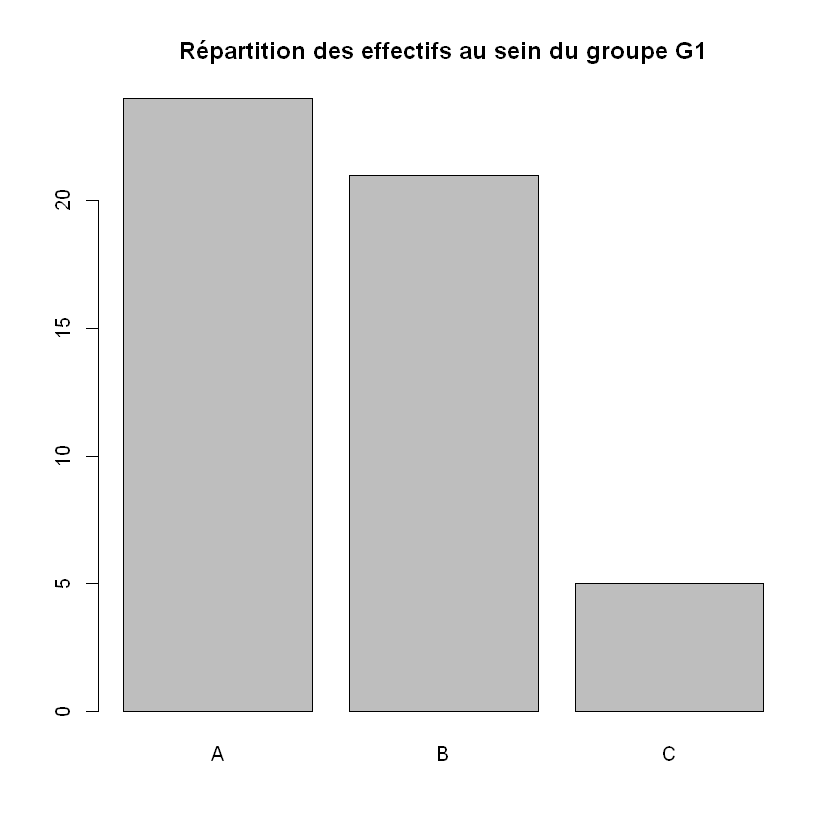

In [32]:
barplot(effectif_urba_g1,
        main = "Répartition des effectifs au sein du groupe G1")

Tracer le barplot représentant les effectifs de la variable `urbanisation_g2` et commentez 

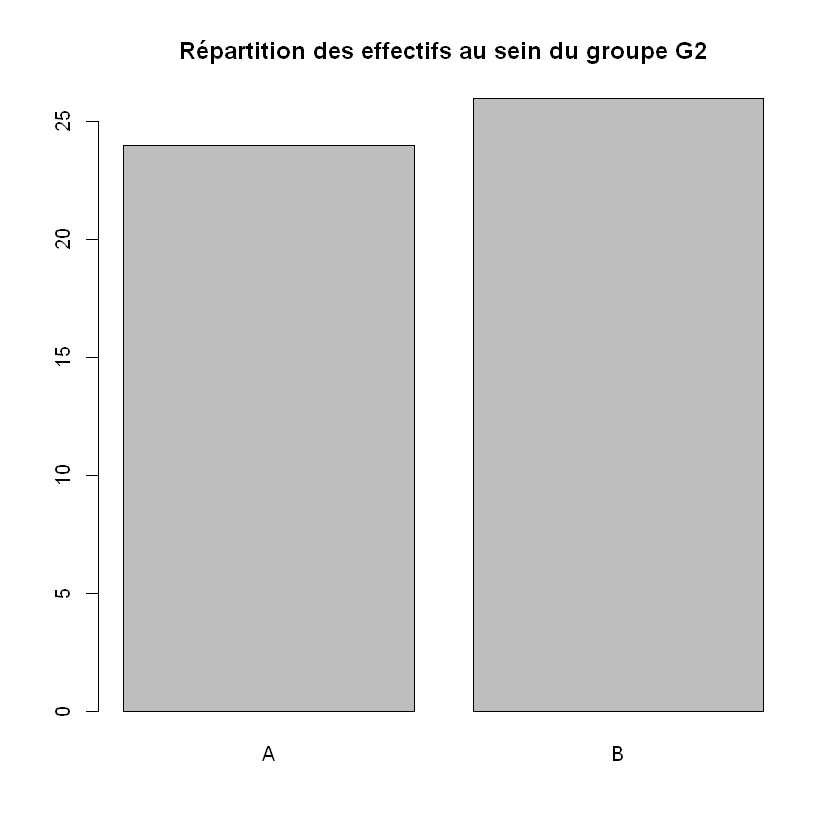

In [33]:
barplot(effectif_urba_g2, main = "Répartition des effectifs au sein du groupe G2")

**Commentaire** :

Au vue de ce graphique deux observations peuvent être faites :
1. la classe "C" de très forte urbanisation a un effectif très faible pour le groupe G1 et nul pour le groupe G2. Pour la suite des analyses, il sera important de procéder à un regroupement entre les classes classes B et C, ce qui évitera des biais dû à un fort déséquilibre entre les classes. Avec ce regroupement, la variable Urbanisation représentera les zones faiblement urbanisées contre les zones urbanisées.
2. La répartition de l’urbanisation entre les deux groupes semble homogène d’après ce graphique.

#### Camemberts (ou diagramme circulaire)

Le camembert permet de représenter les différentes modalités par secteurs angulaires proportionnels
aux fréquences observées.  
Les représentations en camembert sont à utiliser avec modération c’est à dire uniquement lorsqu’il
y a peu de modalités à représenter. En effet, plus il y a de modalités plus il est difficile de lire les proportions sur le graphique. En outre, les camemberts ne représentent que les proportions relatives entre modalités et pas le nombre absolu (contrairement à un diagramme en barres).

Pour représenter un camembert sur R, on peut utiliser la fonction `pie()` (de ***pie** chart* en anglais, littéralement diagramme en tarte = camembert).  
Cette fonction prend comme premier argument les **effectifs** de la variable qualitative à représenter. Comme c'est une fonction graphique on peut utiliser les autres arguments habituels des fonctions graphiques.

*Application au jeu de données sur la variable `urbanisation_g1`*

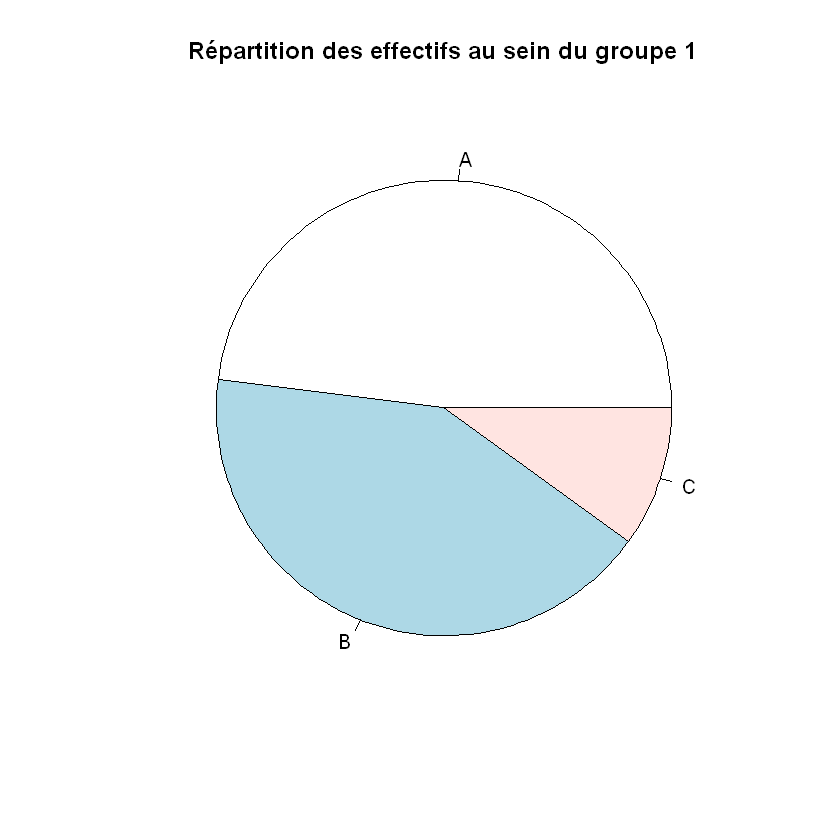

In [34]:
pie(effectif_urba_g1, main = "Répartition des effectifs au sein du groupe 1")

Tracer le camenbert représentant les effectifs de la variable `urbanisation_g2` et commentez 

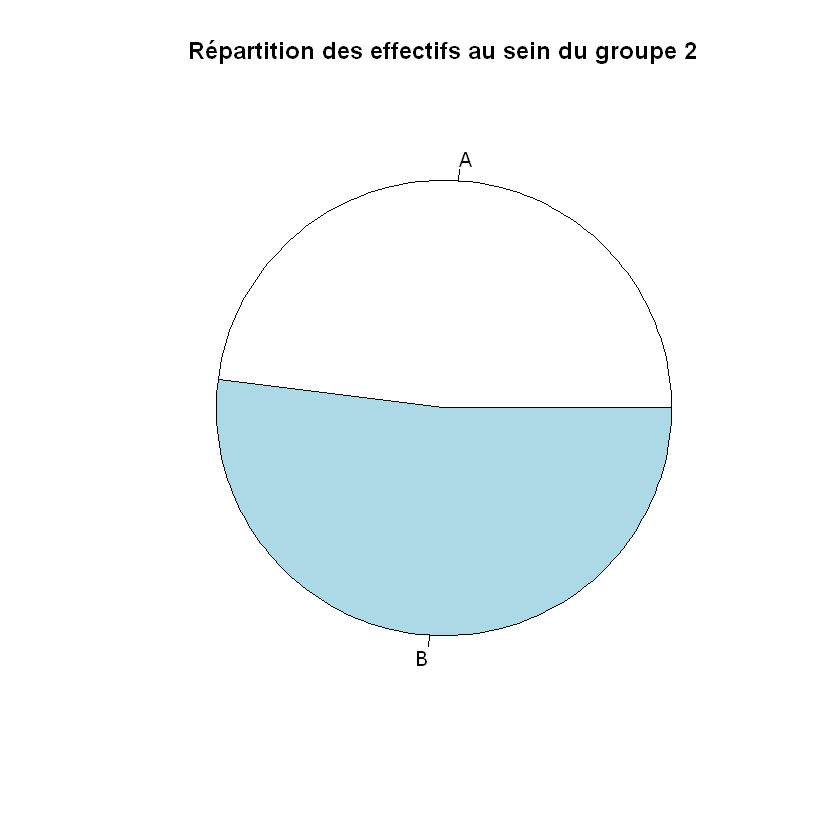

In [35]:
pie(effectif_urba_g2, main = "Répartition des effectifs au sein du groupe 2")

**Commentaire :**



<div class="alert alert-success">

## En résumé

Dans cette séance :

- Nous avons découvert le langage de programmation R
- Nous avons appris à charger des données avec `read.table()`
- Nous avons appris à calculer des statistiques descriptives avec `mean()`, `median()`, `sd()`, `var()`, et `summary()`
- Nous avons appris à faire des graphiques avec `hist()`, `boxplot()`, `barplot()`, et `pie()`
- Nous avons appris à les annoter avec les arguments `main=`, `xlab=`, `ylab=`, et `names()`

</div>

## 6. Exercices d'applications

Ces exercices sont à faire en TD si le temps le permet et à terminer à la maison pour pratiquer d'une séance à l'autre.

### Exercice 1 : comparaison entre groupes

Pour cet exercice, vous allez devoir représenter plusieurs graphiques, n'oubliez pas de bien les annoter en leur donnant un titre ainsi que des titres aux axes pour bien les identifier.

1. Représenter les distributions de variables quantitatives (poids, âge, et score de Hamilton) entre les deux groupes côte-à-côte, les deux groupes sont-ils comparables ?
2. Représenter les répartitions des sexes au sein de chaque groupe, sont-ils comparables ? (Comparez aussi la proportion de femmes entre les groupes)
3. En tenant compte de ce que vous avez étudié plus haut sur les niveaux d'urbanisation, pensez-vous que l'on peut comparer les scores de Hamilton entre ces groupes ? L'échantillonnage a-t-il été adapté ? Si ce n'est pas le cas, comment en tenir compte ?

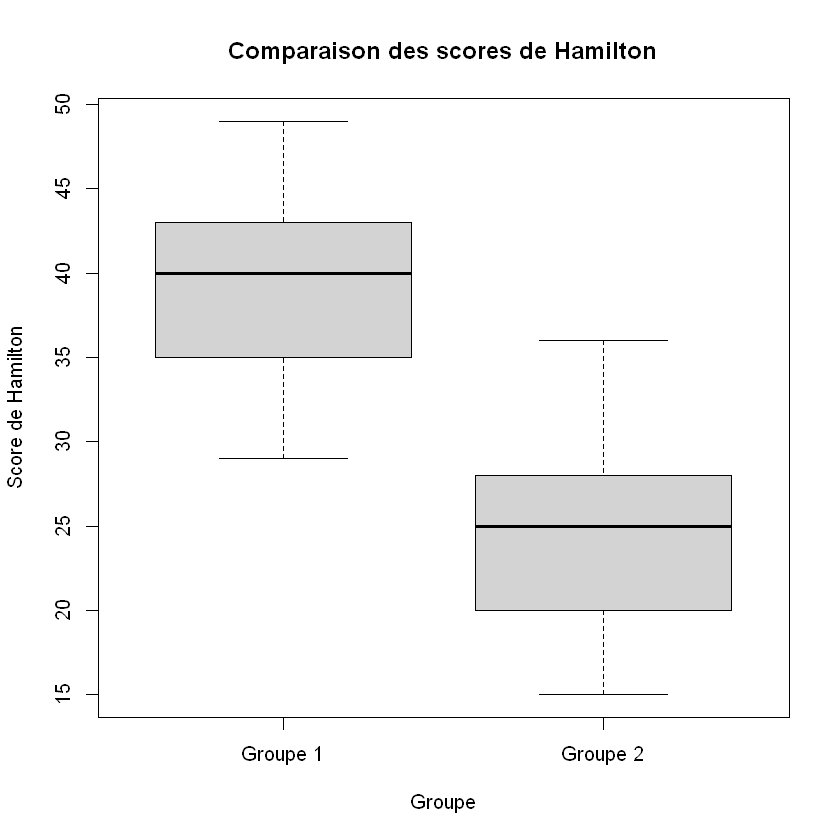

In [36]:
boxplot(depression$hamilton_g1, depression$hamilton_g2, main = "Comparaison des scores de Hamilton", xlab = "Groupe", ylab = "Score de Hamilton", names = c("Groupe 1", "Groupe 2"))

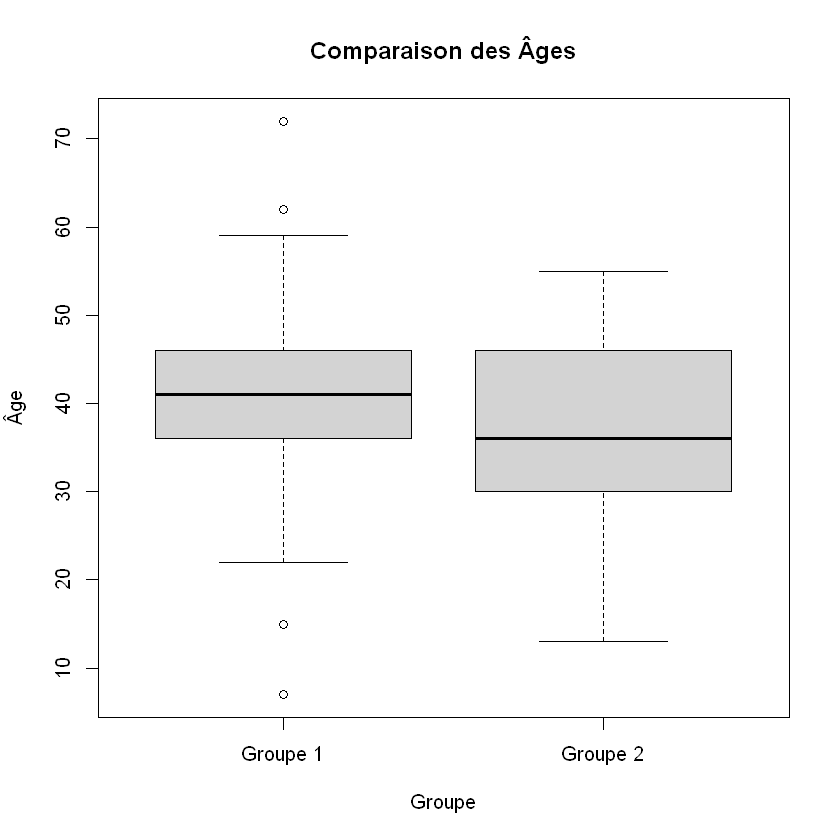

In [37]:
boxplot(depression$age_g1, depression$age_g2, main = "Comparaison des Âges", xlab = "Groupe", ylab = "Âge", names = c("Groupe 1", "Groupe 2"))

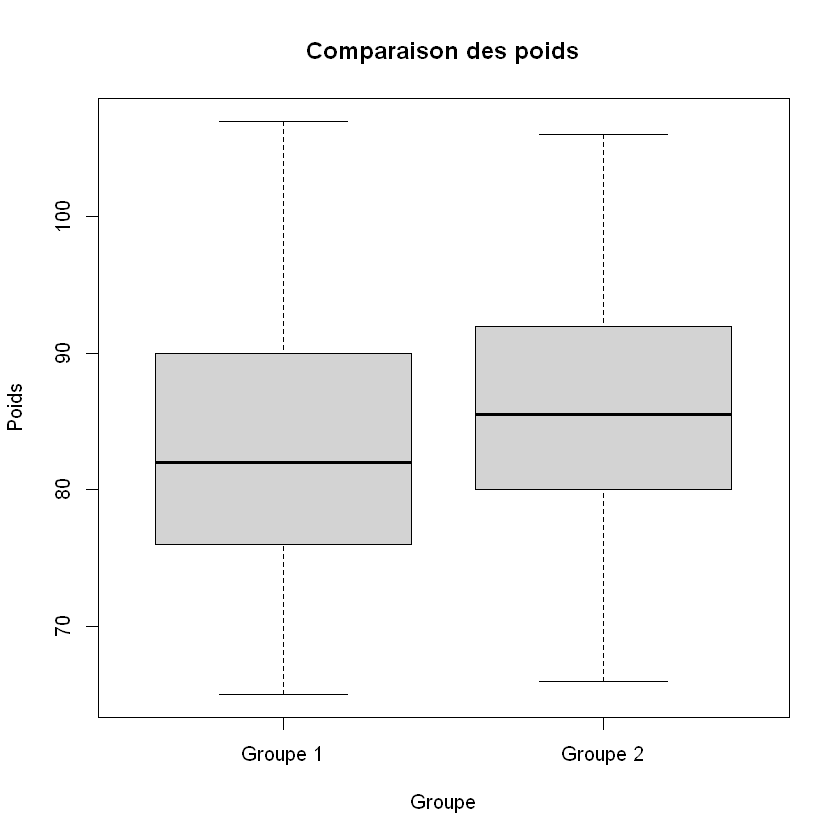

In [38]:
boxplot(depression$poids_g1, depression$poids_g2, main = "Comparaison des poids", xlab = "Groupe", ylab = "Poids", names = c("Groupe 1", "Groupe 2"))

**Réponse Question 1**. Les deux groupes montrent des scores de Hamilton assez différents, mais sont assez similaires sur la répartition du poids et des âges, donc ils devraient être comparables d'après leurs variables quantititatives.


 F  H 
11 39 


 F  H 
 5 45 

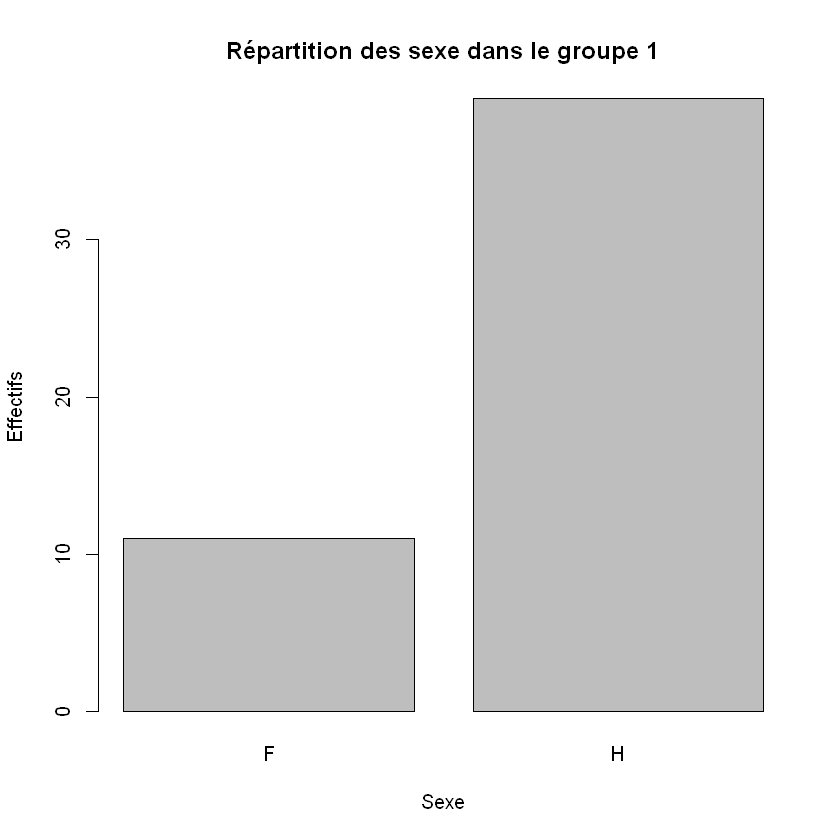

[1] 0.2820513

[1] 0.1111111

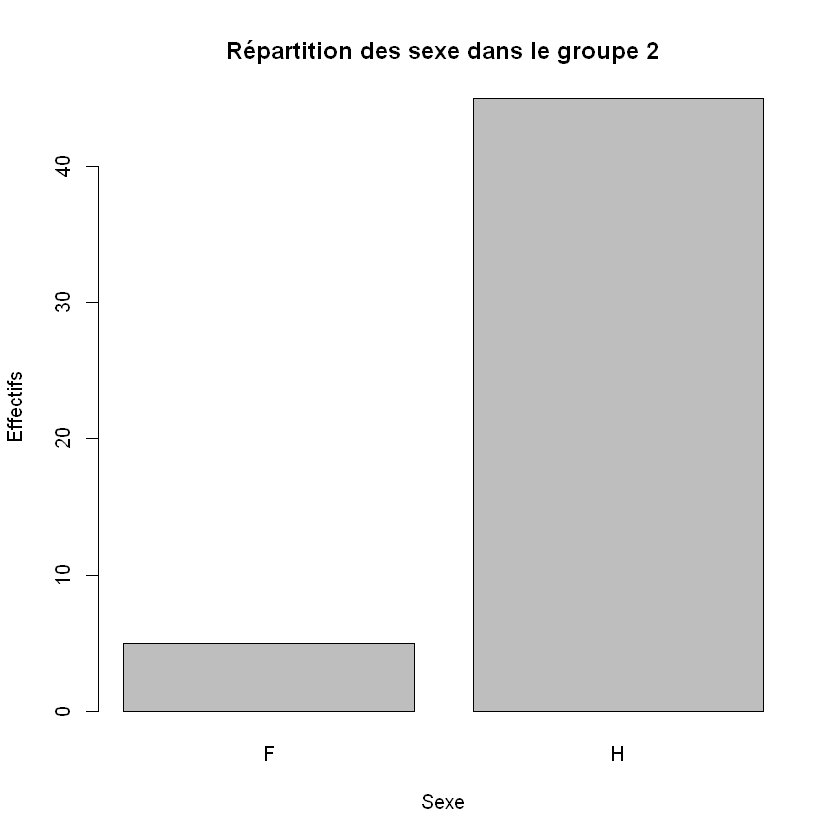

In [39]:
# 2. Représentation de la répartition du sexe entre groupes

eff_sexe_g1 = table(depression$sexe_g1)
eff_sexe_g2 = table(depression$sexe_g2)

eff_sexe_g1
eff_sexe_g2

barplot(eff_sexe_g1, xlab = "Sexe", ylab = "Effectifs", main = "Répartition des sexe dans le groupe 1")
barplot(eff_sexe_g2, xlab = "Sexe", ylab = "Effectifs", main = "Répartition des sexe dans le groupe 2")

11/39
5/45

**Réponse question 2**. On observe davantage de femmes dans le groupe 1 que dans le groupe 2, environ 28% par rapport à 11%, donc il pourrait être difficile de comparer les groupes directement sans tenir compte d'un potentiel effet du sexe.

**Réponse question 3**. Au final les groupes ne semblent pas forcément comparable du fait d'une différence de répartition entre les sexes, et de différences subtiles de niveaux d'urbanisation. Mais on peut comparer au sein des femmes ou au sein des hommes entre les groupes pour palier ces différences.

### Exercice 2 : crédit

Le fichier `credit_approval.txt` dans le dossier `data/` décrit 50 ménages, formés de couples mariés hétérosexuels, tous deux actifs, qui ont déposé une demande de crédit auprès d’un établissement bancaire. Les variables disponibles sont les suivantes :

- `sal.homme` : logarithme du salaire annuel de l’homme,
- `sal.femme` : logarithme du salaire annuel de la femme,
- `rev.tete` : logarithme du revenu par tête c'est‐à‐dire total des revenus divisé par le nombre de personnes,
- `age` : logarithme de l’âge de l’homme,
- `acceptation` : accord du crédit par l’organisme prêteur (valeurs : "oui" ou "non"),
- `garantie.supp` : garantie supplémentaire demandée par l’organisme prêteur (valeurs : "caution", "hypotheque" ou "non"),
- `emploi` : type d’emploi occupé par la personne de référence lors de la demande de crédit (valeurs : "cdd" ou "cdi").

1. Chargez le fichier et vérifiez la dimension du tableau par rapport à ce qui est donné par l'énoncé

In [40]:
credit = read.table("data/credit_approval.txt", header = TRUE)

head(credit)

dim(credit)

# => Il y a bien 50 observations avec les 7 colonnes décrites

,sal.homme,sal.femme,rev.tete,age,acceptation,garantie.supp,emploi
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,7.92,7.72,7.42,3.69,oui,hypotheque,cdd
2,7.97,7.49,7.76,3.89,oui,caution,cdd
3,6.97,7.10,6.35,3.53,non,non,cdd
4,7.85,7.39,7.24,3.78,oui,caution,cdd
5,6.67,6.76,5.46,3.78,oui,hypotheque,cdd
6,6.89,6.51,6.72,4.16,non,hypotheque,cdd


[1] 50  7

2. Que valent les minimum, maximum et quartiles des âges de l'homme ?
   (*indice* : vous pouvez utiliser la fonction `exp()` pour transformer l'âge en années)

In [41]:
summary(credit$age)
summary(exp(credit$age))

# => On observe un âge minimum de 22 ans, un âge maximum de 64 ans, un âge de médian de 42 ans, avec Q1 = 32 ans et Q3 = 45 ans.

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  3.090   3.478   3.740   3.691   3.825   4.160 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  21.98   32.38   42.10   41.46   45.83   64.07 

3. Combien de couples ont vu leur prêt accepté ?

In [42]:
table(credit$acceptation)

# => 34 couples sur 50 ont vu leur prêt accepté


non oui 
 16  34 

4. Comparez les distributions des salaires mensuels des hommes et des femmes
   (pour obtenir les salaires en valeurs réelles il faut utiliser la fonction `exp()`)

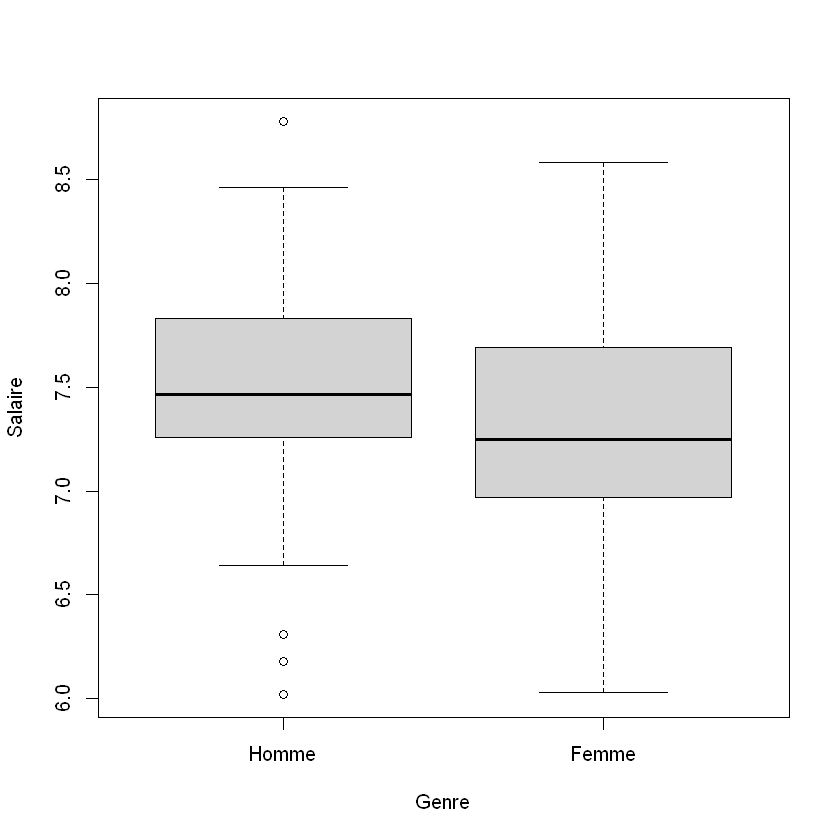

In [43]:
boxplot(credit$sal.homme, credit$sal.femme, xlab = "Genre", ylab = "Salaire", names = c("Homme", "Femme"))

# => Les hommes ont un salaire plus élevés en moyenne que les femmes

5. Calculez la différence de salaire au sein d'un couple entre les hommes et les femmes. Représentez-la. Qu'observez-vous ?
   (*indice* : vous pouvez faire des opérations, comme des soustractions, sur des colonnes entière)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-820.44  -77.06  301.56  326.50  706.38 1525.99 

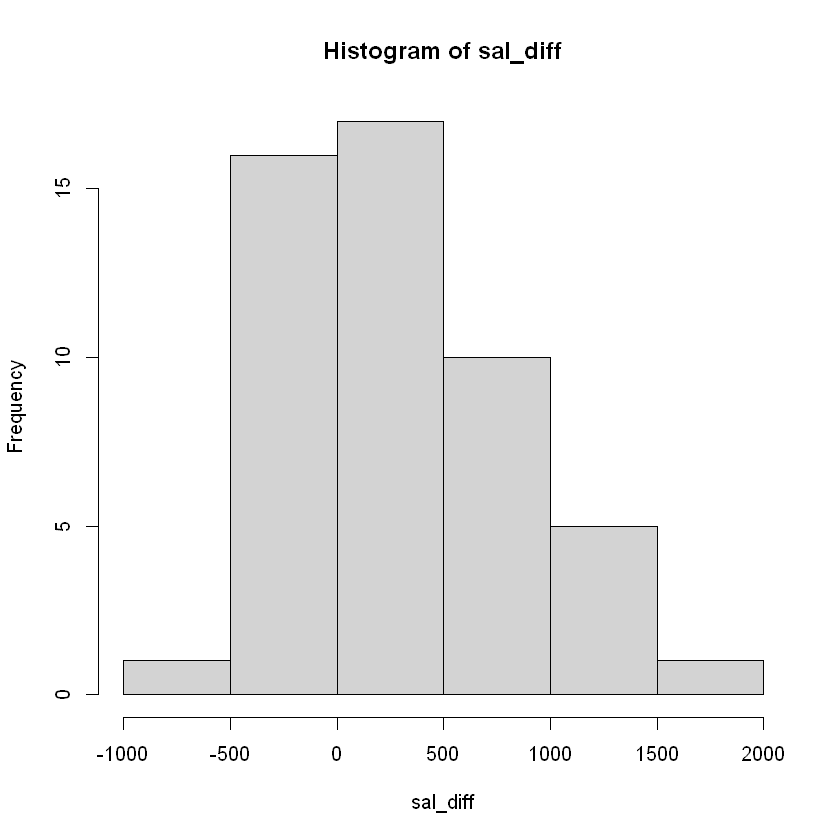

In [44]:
sal_diff = exp(credit$sal.homme) - exp(credit$sal.femme)

summary(sal_diff)

hist(sal_diff)

In [45]:
# => En moyenne, les hommes gagnent 326€ de plus par mois que les femmes dans le couples
# Mais dans le couple avec la plus petite différence, l'homme gagne 800€ de moins que la femme

6. Représentez graphiquement les garanties supplémentaires demandées, quelle garantie est la plus fréquemment demandée ?

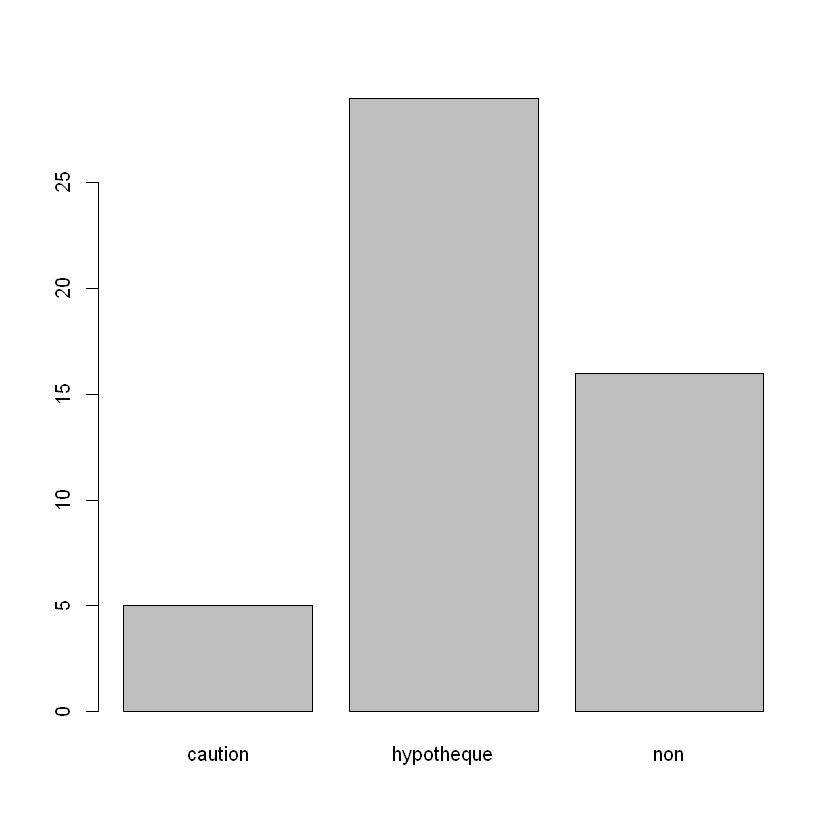

In [46]:
barplot(table(credit$garantie.supp))

# => Il s'agit de l'hypothèque

7. Quel type d'emploi des hommes est le plus fréquent ?

In [47]:
table(credit$emploi)


cdd cdi 
 16  34 